# 03 — Interpretabilidade
## O que move a predição de alfabetização

Duas técnicas complementares sobre o modelo final (LightGBM):

- **Permutation importance** (na pipeline inteira, sobre as features originais):
  quanto a AUC cai quando cada variável é embaralhada no teste de 2024;
- **SHAP values**: contribuição de cada variável para cada previsão individual —
  direção e magnitude, global e caso a caso.

In [1]:
import sys
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sys.path.insert(0, "..")
from src.preprocessing.pipeline import ALL_FEATURES, TARGET, load_dataset

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
IMG = Path("../images")
SEED = 42

modelo = joblib.load("../data/modelo_final.joblib")
df = load_dataset("../data/gold_base_ml_alunos.parquet")
teste = df[df["ano"] == 2024]
amostra = teste.sample(30_000, random_state=SEED)
print(f"amostra de interpretabilidade: {len(amostra):,} alunos do teste 2024")

amostra de interpretabilidade: 30,000 alunos do teste 2024


## 1. Permutation importance (features originais, AUC no teste)

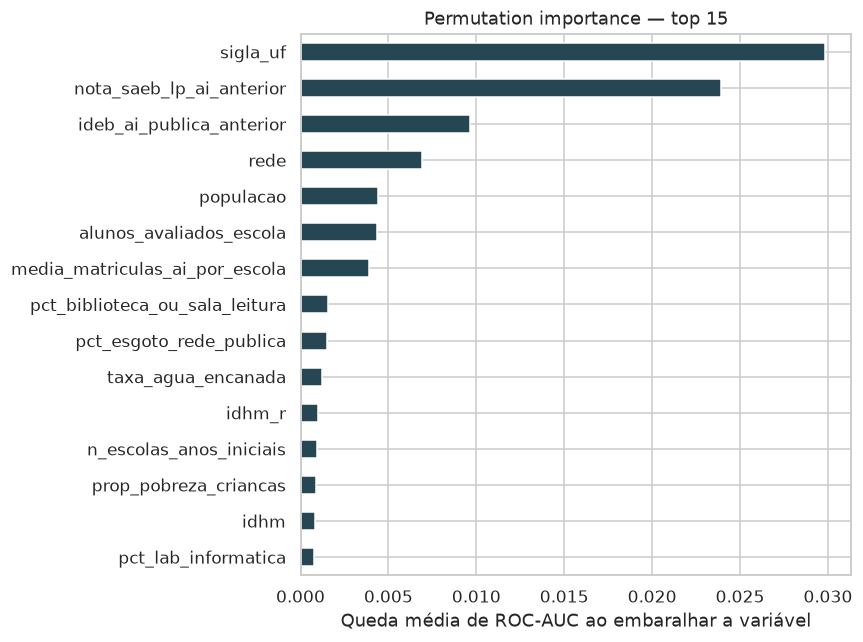

sigla_uf                          0.0298
nota_saeb_lp_ai_anterior          0.0239
ideb_ai_publica_anterior          0.0096
rede                              0.0069
populacao                         0.0044
alunos_avaliados_escola           0.0043
media_matriculas_ai_por_escola    0.0039
pct_biblioteca_ou_sala_leitura    0.0016
pct_esgoto_rede_publica           0.0015
taxa_agua_encanada                0.0012
idhm_r                            0.0010
n_escolas_anos_iniciais           0.0009
prop_pobreza_criancas             0.0009
idhm                              0.0008
pct_lab_informatica               0.0008
dtype: float64

In [2]:
from sklearn.inspection import permutation_importance

pi = permutation_importance(
    modelo, amostra[ALL_FEATURES], amostra[TARGET],
    scoring="roc_auc", n_repeats=5, random_state=SEED, n_jobs=4)
imp = (pd.Series(pi.importances_mean, index=ALL_FEATURES)
         .sort_values().tail(15))
fig, ax = plt.subplots(figsize=(8, 6))
imp.plot.barh(ax=ax, color="#264653")
ax.set_xlabel("Queda média de ROC-AUC ao embaralhar a variável")
ax.set_title("Permutation importance — top 15")
plt.tight_layout()
plt.savefig(IMG / "interp_permutation.png", bbox_inches="tight")
plt.show()
imp.round(4).iloc[::-1]

## 2. SHAP — visão global

Beeswarm: cada ponto é um aluno; a posição horizontal é o empurrão da variável
na previsão (direita = mais provável alfabetizado), a cor é o valor da variável
(vermelho alto, azul baixo).

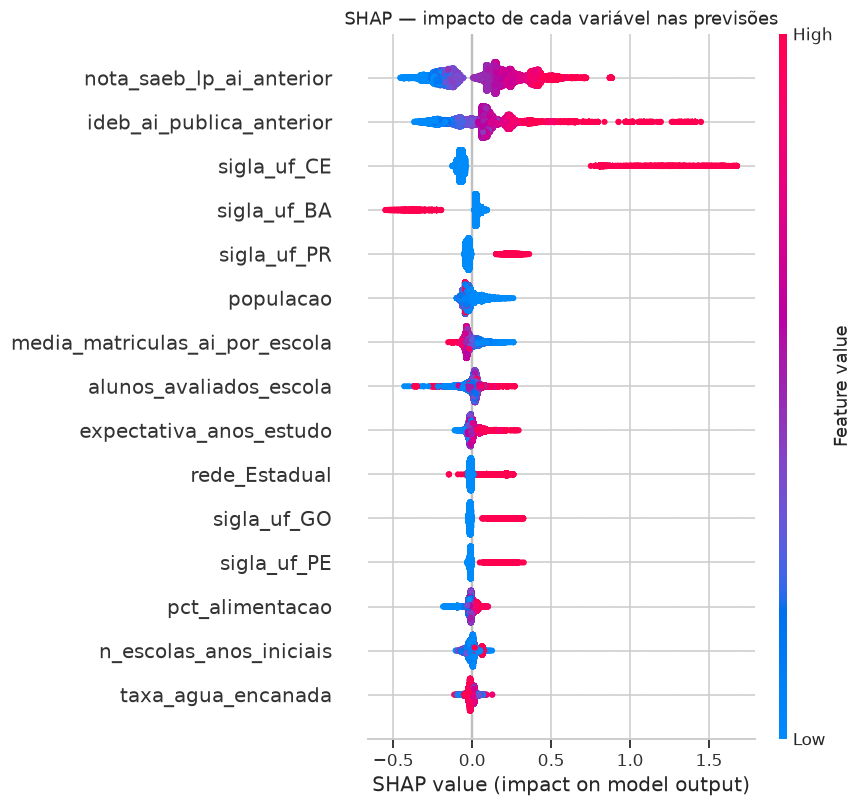

In [3]:
import shap

prep = modelo.named_steps["prep"]
lgbm = modelo.named_steps["model"]
Xs = prep.transform(amostra[ALL_FEATURES])
nomes = prep.get_feature_names_out()
Xs_dense = pd.DataFrame(
    Xs.toarray() if hasattr(Xs, "toarray") else Xs, columns=nomes)

explainer = shap.TreeExplainer(lgbm)
sv = explainer(Xs_dense)
# classificador binário: pega a dimensão da classe positiva se houver
valores = sv.values if sv.values.ndim == 2 else sv.values[:, :, 1]
shap.summary_plot(valores, Xs_dense, max_display=15, show=False)
plt.title("SHAP — impacto de cada variável nas previsões")
plt.tight_layout()
plt.savefig(IMG / "interp_shap_beeswarm.png", bbox_inches="tight")
plt.show()

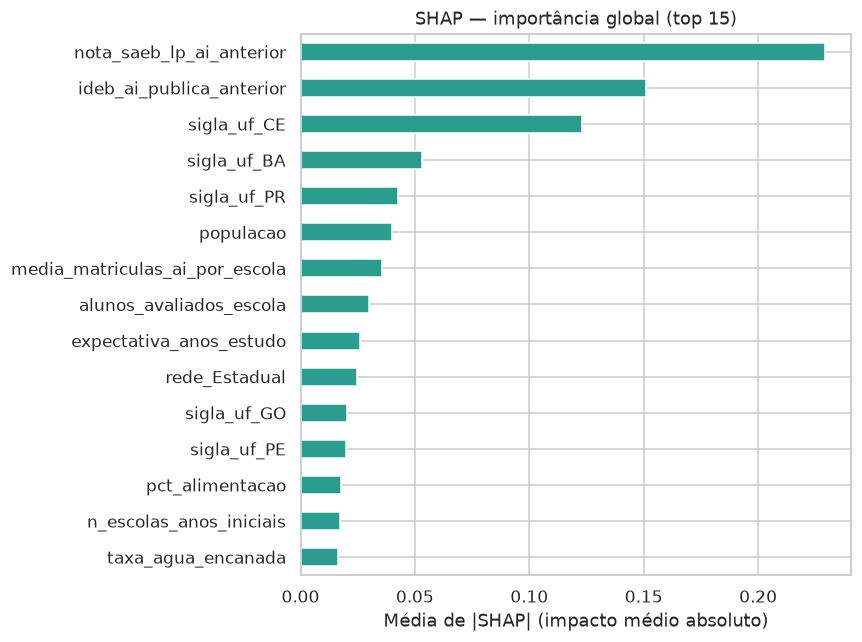

In [4]:
media_abs = pd.Series(np.abs(valores).mean(axis=0), index=nomes)
top = media_abs.sort_values().tail(15)
fig, ax = plt.subplots(figsize=(8, 6))
top.plot.barh(ax=ax, color="#2a9d8f")
ax.set_xlabel("Média de |SHAP| (impacto médio absoluto)")
ax.set_title("SHAP — importância global (top 15)")
plt.tight_layout()
plt.savefig(IMG / "interp_shap_bar.png", bbox_inches="tight")
plt.show()

## 3. Dois alunos, duas histórias

Waterfall de um aluno de **alto risco** e um de **baixo risco**: como o contexto
soma até a previsão final.

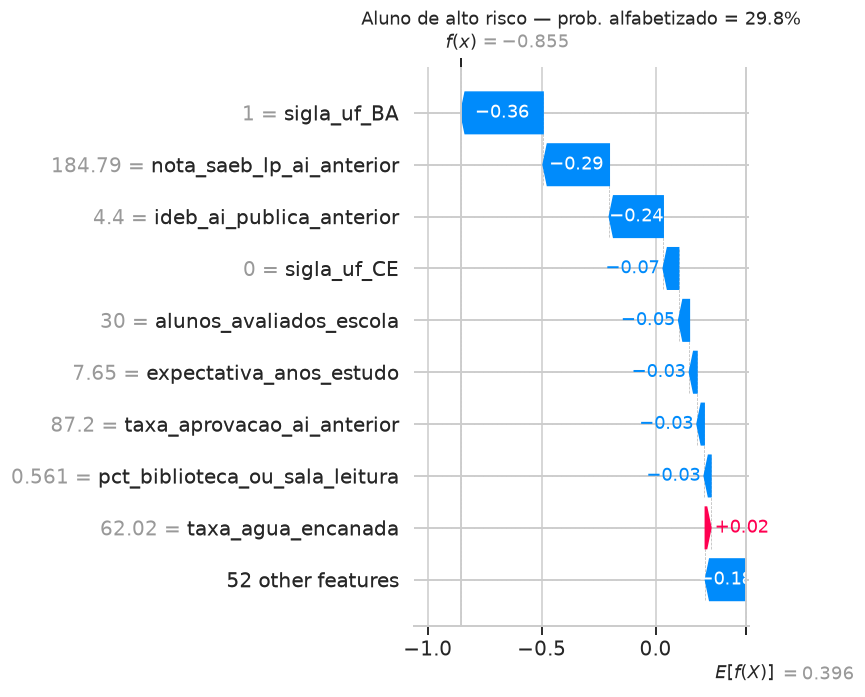

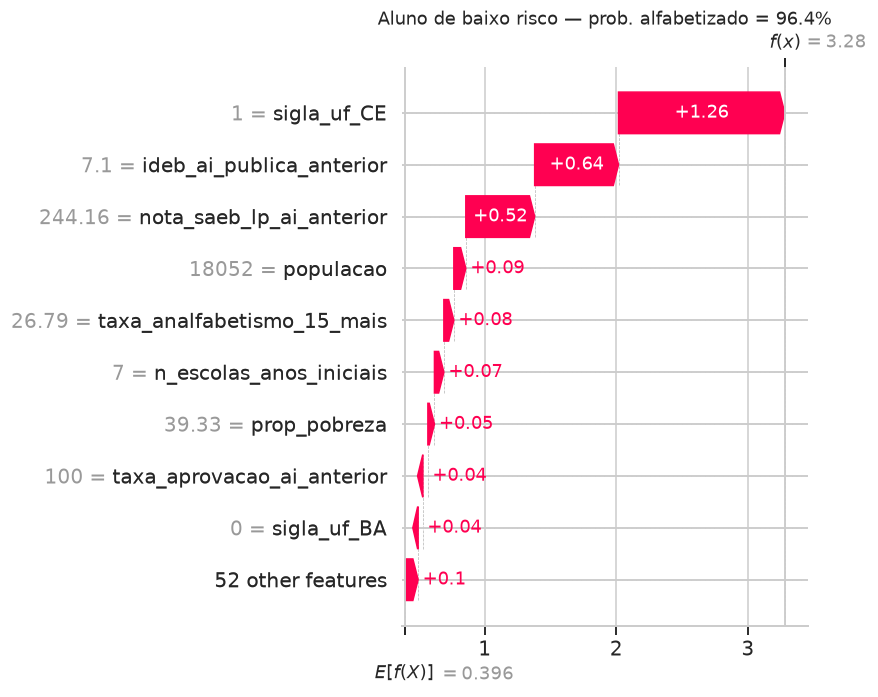

In [5]:
probs = modelo.predict_proba(amostra[ALL_FEATURES])[:, 1]
i_risco = int(np.argsort(probs)[len(probs) // 100])          # percentil 1 (alto risco)
i_ok = int(np.argsort(probs)[-len(probs) // 100])            # percentil 99 (baixo risco)
for i, rotulo in [(i_risco, "alto_risco"), (i_ok, "baixo_risco")]:
    ex = shap.Explanation(values=valores[i], base_values=(
        sv.base_values[i] if np.ndim(sv.base_values) == 1 else sv.base_values[i, 1]),
        data=Xs_dense.iloc[i], feature_names=list(nomes))
    shap.plots.waterfall(ex, max_display=10, show=False)
    plt.title(f"Aluno de {rotulo.replace('_', ' ')} — prob. alfabetizado = {probs[i]:.1%}")
    plt.tight_layout()
    plt.savefig(IMG / f"interp_waterfall_{rotulo}.png", bbox_inches="tight")
    plt.show()

## 4. Tradução para o gestor público

O que as duas técnicas mostram, na ordem que o dado impôs:

1. **A UF é o sinal mais forte.** Saber o estado da criança move a AUC mais que
   qualquer outra variável. Leitura: as diferenças **estaduais de política
   educacional** (regime de colaboração, programas de alfabetização
   consolidados — o contraste Ceará × médias do Norte é o exemplo clássico)
   pesam mais que o nível socioeconômico do município em si.
2. **Histórico educacional recente da rede municipal** (nota Saeb de Língua
   Portuguesa e IDEB dos anos iniciais, edição anterior) vem logo atrás —
   desempenho passado da rede prediz o presente da criança.
3. **Rede (municipal × estadual) e porte** (população do município, tamanho da
   escola avaliada) têm efeito próprio menor, porém consistente.
4. **Socioeconômico e infraestrutura aparecem diluídos** na importância
   individual (IDHM, pobreza, internet ≈ 0,001 cada). Não é que não importem —
   a EDA mostrou correlação municipal clara; é que a UF e o histórico do IDEB
   **já carregam** boa parte dessa informação (colinearidade). Para o modelo
   preditivo eles são substituíveis; para o diagnóstico causal, não se conclui
   daqui que pobreza não importa.

Implicação: o modelo funciona como **instrumento de focalização** — aponta onde
o risco se concentra **antes** da avaliação acontecer. E o peso da UF sugere que
a alavanca mais poderosa conhecida é **política estadual estruturada de
alfabetização**, não apenas transferir renda ou infraestrutura.